# AIME2 vs LIME vs KernelSHAP on Breast Cancer Wisconsin (review-ready, bug-fixed)

## Outputs
- `tables/table_similarity_bugfixed.tex`
- `tables/table_runtime_bugfixed.tex`
- `figs/fig_mean_top10_comparison_bugfixed.png`
- `results/instance_level_metrics_bugfixed.csv`
- `results/mean_feature_weights_bugfixed.csv`


In [12]:
# If needed, uncomment:
# !pip install lime shap

In [13]:

import os
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

warnings.filterwarnings("ignore")

try:
    import shap
except Exception as e:
    raise ImportError("Please install shap: pip install shap") from e

try:
    from lime.lime_tabular import LimeTabularExplainer
except Exception as e:
    raise ImportError("Please install lime: pip install lime") from e

os.makedirs("./add_result/tables", exist_ok=True)
os.makedirs("./add_result/figs", exist_ok=True)
os.makedirs("./add_result/results", exist_ok=True)

RANDOM_STATE = 42
TARGET_LABEL = 1  # malignant in sklearn breast cancer dataset
EPS = 1e-12


In [14]:

# Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# sklearn target: 0=malignant, 1=benign for this dataset.
# We want malignant probability, so define a malignant label explicitly.
y_malignant = (y == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_malignant, test_size=0.25, random_state=RANDOM_STATE, stratify=y_malignant
)

feature_names = list(X.columns)
d = X_train.shape[1]

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1
)
clf.fit(X_train, y_train)

print("Train/Test:", X_train.shape, X_test.shape)
print("d =", d)
print("Target positive = malignant")
print("Test malignant probability summary:",
      pd.Series(clf.predict_proba(X_test)[:, 1]).describe())


Train/Test: (426, 30) (143, 30)
d = 30
Target positive = malignant
Test malignant probability summary: count    143.000000
mean       0.347599
std        0.423863
min        0.000000
25%        0.006667
50%        0.073333
75%        0.896667
max        1.000000
dtype: float64


In [15]:

# Select confidently malignant test cases
test_probs = clf.predict_proba(X_test)[:, 1]
conf_mask = test_probs >= 0.90
X_eval = X_test.loc[conf_mask].copy()
p_eval = test_probs[conf_mask]

if len(X_eval) == 0:
    raise RuntimeError("No confidently malignant test cases found. Lower the threshold.")

print(f"Selected {len(X_eval)} confidently malignant cases.")


Selected 36 confidently malignant cases.


In [16]:

@dataclass
class MethodOutput:
    raw: np.ndarray          # raw signed or unsigned vector (30,)
    normalized_abs: np.ndarray  # abs(raw) / sum(abs(raw))
    runtime_ms: float

def normalize_abs(vec: np.ndarray, method_name: str) -> np.ndarray:
    vec = np.asarray(vec, dtype=float).reshape(-1)
    if vec.shape[0] != d:
        raise ValueError(f"{method_name}: expected shape ({d},), got {vec.shape}")
    abs_vec = np.abs(vec)
    s = float(abs_vec.sum())
    if not np.isfinite(s) or s <= EPS:
        raise ValueError(f"{method_name}: absolute attribution sum is invalid ({s}).")
    norm = abs_vec / s
    # strict checks
    if norm.shape[0] != d:
        raise ValueError(f"{method_name}: normalized vector shape mismatch.")
    if not np.all(np.isfinite(norm)):
        raise ValueError(f"{method_name}: non-finite normalized values detected.")
    if not np.isclose(norm.sum(), 1.0, atol=1e-8):
        raise ValueError(f"{method_name}: normalized abs sum != 1. Got {norm.sum()}")
    return norm

def topk_overlap(a: np.ndarray, b: np.ndarray, k: int = 5) -> float:
    ia = set(np.argsort(a)[-k:])
    ib = set(np.argsort(b)[-k:])
    return len(ia.intersection(ib)) / k

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    den = np.linalg.norm(a) * np.linalg.norm(b)
    if den <= EPS:
        return np.nan
    return float(np.dot(a, b) / den)

def spearman_abs(a: np.ndarray, b: np.ndarray) -> float:
    # rank correlation on normalized absolute vectors
    sa = pd.Series(a)
    sb = pd.Series(b)
    return float(sa.corr(sb, method="spearman"))

def gaussian_kernel_weights(X_local: np.ndarray, x0: np.ndarray, kernel_width: float) -> np.ndarray:
    dist2 = np.sum((X_local - x0[None, :])**2, axis=1)
    w = np.exp(-dist2 / (kernel_width**2 + EPS))
    return w

def local_aime2_attribution(
    x0: np.ndarray,
    model,
    X_reference: np.ndarray,
    n_samples: int = 600,
    noise_scale: float = 0.25,
    kernel_width: float = 2.5,
    ridge_lambda: float = 1e-4,
    random_state: int = 42,
) -> MethodOutput:
    '''
    Local weighted inverse-style attribution.
    We build a local weighted linear surrogate around x0 and convert coefficients
    into local contribution values using (x0 - mu_local).
    '''
    t0 = time.perf_counter()
    rng = np.random.default_rng(random_state)

    sigma = X_reference.std(axis=0, ddof=0)
    sigma = np.where(sigma < 1e-8, 1e-8, sigma)

    noise = rng.normal(0.0, noise_scale, size=(n_samples, d)) * sigma[None, :]
    X_local = x0[None, :] + noise

    # Add the instance itself to stabilize the surrogate
    X_local = np.vstack([x0[None, :], X_local])

    # Model output: malignant probability
    y_local = model.predict_proba(X_local)[:, 1]

    # Local centering
    mu = X_local.mean(axis=0)
    Xc = X_local - mu[None, :]
    yc = y_local - y_local.mean()

    # Distance weights centered at x0
    w = gaussian_kernel_weights(X_local, x0, kernel_width=kernel_width)
    Wsqrt = np.sqrt(w + EPS)[:, None]

    Xw = Xc * Wsqrt
    yw = yc * np.sqrt(w + EPS)

    # Weighted ridge surrogate
    beta = np.linalg.solve(Xw.T @ Xw + ridge_lambda * np.eye(d), Xw.T @ yw)

    # Contribution values for the target point x0
    phi = beta * (x0 - mu)

    runtime_ms = (time.perf_counter() - t0) * 1000.0
    return MethodOutput(raw=phi, normalized_abs=normalize_abs(phi, "AIME2"), runtime_ms=runtime_ms)

# LIME explainer initialized once
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=["benign", "malignant"],  # only display labels; our target label below is numeric
    mode="classification",
    discretize_continuous=False,
    random_state=RANDOM_STATE
)

def lime_fullvector_attribution(
    x0: np.ndarray,
    model,
    num_samples: int = 5000,
) -> MethodOutput:
    t0 = time.perf_counter()
    exp = lime_explainer.explain_instance(
        data_row=x0,
        predict_fn=model.predict_proba,
        num_features=d,          # force full vector
        labels=(1,),             # malignant probability
        num_samples=num_samples
    )
    if 1 not in exp.local_exp:
        raise RuntimeError("LIME did not return the requested target label 1.")
    pairs = exp.local_exp[1]
    if len(pairs) != d:
        # Some versions can still return fewer terms; fail fast rather than silently plotting wrong values.
        raise RuntimeError(f"LIME returned {len(pairs)} features, expected {d}.")
    phi = np.zeros(d, dtype=float)
    for j, w in pairs:
        phi[int(j)] = float(w)

    runtime_ms = (time.perf_counter() - t0) * 1000.0
    return MethodOutput(raw=phi, normalized_abs=normalize_abs(phi, "LIME"), runtime_ms=runtime_ms)

# Background for TreeExplainer
background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
shap_explainer = shap.TreeExplainer(clf, data=background, feature_perturbation="interventional", model_output="probability")

def shap_fullvector_attribution(x0: np.ndarray) -> MethodOutput:
    t0 = time.perf_counter()
    sv = shap_explainer.shap_values(x0.reshape(1, -1))

    # Robust handling across SHAP versions
    if isinstance(sv, list):
        if len(sv) < 2:
            raise RuntimeError(f"Unexpected SHAP list length: {len(sv)}")
        phi = np.asarray(sv[1]).reshape(-1)
    else:
        arr = np.asarray(sv)
        if arr.ndim == 3:
            # (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features)
            if arr.shape[0] == 1 and arr.shape[2] == 2:
                phi = arr[0, :, 1].reshape(-1)
            elif arr.shape[0] == 2 and arr.shape[1] == 1:
                phi = arr[1, 0, :].reshape(-1)
            elif arr.shape[0] == 1 and arr.shape[1] == d and arr.shape[2] == 2:
                phi = arr[0, :, 1].reshape(-1)
            else:
                raise RuntimeError(f"Unexpected SHAP array shape: {arr.shape}")
        elif arr.ndim == 2:
            # (n_samples, n_features)
            phi = arr.reshape(-1)
        else:
            raise RuntimeError(f"Unexpected SHAP output shape: {arr.shape}")

    if phi.shape[0] != d:
        raise RuntimeError(f"SHAP returned shape {phi.shape}, expected ({d},)")
    runtime_ms = (time.perf_counter() - t0) * 1000.0
    return MethodOutput(raw=phi, normalized_abs=normalize_abs(phi, "KernelSHAP"), runtime_ms=runtime_ms)


In [17]:

# Main loop with strict validation
records = []
norm_aime2_all = []
norm_lime_all = []
norm_shap_all = []

for idx, (row_idx, row) in enumerate(X_eval.iterrows()):
    x0 = row.values.astype(float)
    p0 = float(clf.predict_proba(x0.reshape(1, -1))[0, 1])

    out_aime2 = local_aime2_attribution(
        x0=x0,
        model=clf,
        X_reference=X_train.values,
        n_samples=700,
        noise_scale=0.20,
        kernel_width=2.5,
        ridge_lambda=1e-4,
        random_state=RANDOM_STATE + idx
    )
    out_lime = lime_fullvector_attribution(x0=x0, model=clf, num_samples=4000)
    out_shap = shap_fullvector_attribution(x0=x0)

    # hard assertions to catch bugs
    assert out_aime2.normalized_abs.shape == (d,)
    assert out_lime.normalized_abs.shape == (d,)
    assert out_shap.normalized_abs.shape == (d,)
    assert np.isclose(out_aime2.normalized_abs.sum(), 1.0, atol=1e-8)
    assert np.isclose(out_lime.normalized_abs.sum(), 1.0, atol=1e-8)
    assert np.isclose(out_shap.normalized_abs.sum(), 1.0, atol=1e-8)

    norm_aime2_all.append(out_aime2.normalized_abs)
    norm_lime_all.append(out_lime.normalized_abs)
    norm_shap_all.append(out_shap.normalized_abs)

    records.append({
        "instance": f"test_{row_idx}",
        "test_index": int(row_idx),
        "malignant_probability": p0,
        "AIME2_runtime_ms": out_aime2.runtime_ms,
        "LIME_runtime_ms": out_lime.runtime_ms,
        "KernelSHAP_runtime_ms": out_shap.runtime_ms,
        "Spearman rank correlation of absolute weights with LIME": spearman_abs(out_aime2.normalized_abs, out_lime.normalized_abs),
        "Cosine similarity of absolute weights with LIME": cosine_similarity(out_aime2.normalized_abs, out_lime.normalized_abs),
        "Top-5 feature overlap with LIME": topk_overlap(out_aime2.normalized_abs, out_lime.normalized_abs, k=5),
        "Spearman rank correlation of absolute weights with KernelSHAP": spearman_abs(out_aime2.normalized_abs, out_shap.normalized_abs),
        "Cosine similarity of absolute weights with KernelSHAP": cosine_similarity(out_aime2.normalized_abs, out_shap.normalized_abs),
        "Top-5 feature overlap with KernelSHAP": topk_overlap(out_aime2.normalized_abs, out_shap.normalized_abs, k=5),
    })

instance_df = pd.DataFrame(records)
instance_df.to_csv("./add_result/results/instance_level_metrics_bugfixed.csv", index=False)

print(instance_df.head())
print("\nMean metrics:\n")
print(instance_df.mean(numeric_only=True))


   instance  test_index  malignant_probability  AIME2_runtime_ms  \
0   test_12          12               0.956667         27.664333   
1  test_321         321               0.926667         23.721833   
2  test_479         479               0.970000         27.556875   
3  test_218         218               1.000000         25.742791   
4  test_562         562               0.980000         26.406583   

   LIME_runtime_ms  KernelSHAP_runtime_ms  \
0        31.314125               8.271666   
1        31.142916               7.823166   
2        30.852166               7.353250   
3        29.790667               7.159917   
4        27.495833               7.669958   

   Spearman rank correlation of absolute weights with LIME  \
0                                           0.664516         
1                                           0.754394         
2                                           0.670300         
3                                           0.691657         
4         

In [18]:

# Mean feature weights (correct order: per-instance full-vector normalize -> mean -> joint top-10)
mean_aime2 = np.mean(np.vstack(norm_aime2_all), axis=0)
mean_lime = np.mean(np.vstack(norm_lime_all), axis=0)
mean_shap = np.mean(np.vstack(norm_shap_all), axis=0)

# validation
for name, vec in [("AIME2", mean_aime2), ("LIME", mean_lime), ("KernelSHAP", mean_shap)]:
    assert vec.shape == (d,)
    assert np.all(np.isfinite(vec))
    # mean of normalized vectors should still sum to 1 (up to tiny numerical error)
    assert np.isclose(vec.sum(), 1.0, atol=1e-6), f"{name} mean vector sum = {vec.sum()}"

mean_feature_weights = pd.DataFrame({
    "feature": feature_names,
    "AIME2": mean_aime2,
    "LIME": mean_lime,
    "KernelSHAP": mean_shap
}).sort_values(by=["AIME2", "LIME", "KernelSHAP"], ascending=False)

mean_feature_weights.to_csv("./add_result/results/mean_feature_weights_bugfixed.csv", index=False)

joint_score = mean_aime2 + mean_lime + mean_shap
top_idx = np.argsort(joint_score)[-10:]
top_idx = top_idx[np.argsort(joint_score[top_idx])]  # ascending for horizontal bar plot

plot_df = pd.DataFrame({
    "feature": np.array(feature_names)[top_idx],
    "AIME2": mean_aime2[top_idx],
    "LIME": mean_lime[top_idx],
    "KernelSHAP": mean_shap[top_idx],
})
plot_df


,feature,AIME2,LIME,KernelSHAP
0,worst texture,4.462882e-04,0.056946,0.028489
1,mean concavity,6.815558e-08,0.037839,0.050825
2,worst concavity,6.149982e-07,0.047000,0.046720
3,area error,2.294765e-02,0.060794,0.056725
4,mean concave points,3.920544e-08,0.063793,0.092988
5,worst concave points,6.038470e-08,0.081694,0.101345
6,worst radius,5.840744e-04,0.091397,0.099215
7,worst perimeter,1.189770e-02,0.127816,0.137877
8,mean area,3.927223e-01,0.043418,0.050578
9,worst area,5.597224e-01,0.116267,0.132147


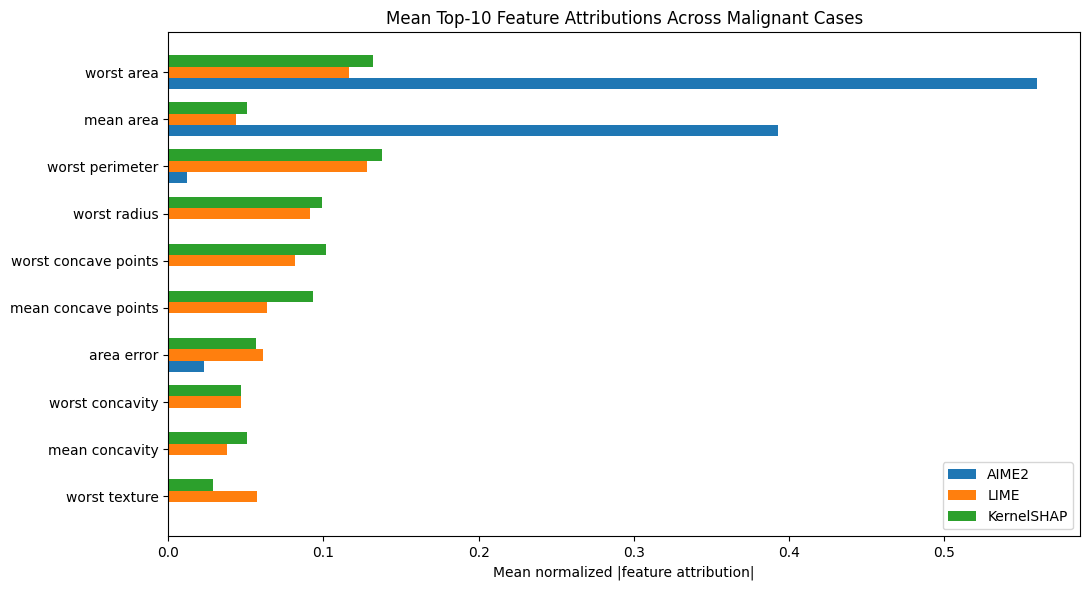

In [19]:

# Paper-ready figure: mean Top-10 across malignant cases
plt.figure(figsize=(11, 6))
ypos = np.arange(len(plot_df))
h = 0.24

plt.barh(ypos - h, plot_df["AIME2"], height=h, label="AIME2")
plt.barh(ypos, plot_df["LIME"], height=h, label="LIME")
plt.barh(ypos + h, plot_df["KernelSHAP"], height=h, label="KernelSHAP")

plt.yticks(ypos, plot_df["feature"])
plt.xlabel("Mean normalized |feature attribution|")
plt.title("Mean Top-10 Feature Attributions Across Malignant Cases")
plt.legend()
plt.tight_layout()
plt.savefig("./add_result/figs/fig_mean_top10_comparison_bugfixed.png", dpi=220, bbox_inches="tight")
plt.show()


In [20]:

# Tables
sim_rows = [
    ["Spearman correlation of absolute full-vector weights", 
     instance_df["Spearman rank correlation of absolute weights with LIME"].mean(),
     instance_df["Spearman rank correlation of absolute weights with KernelSHAP"].mean()],
    ["Cosine similarity of absolute full-vector weights", 
     instance_df["Cosine similarity of absolute weights with LIME"].mean(),
     instance_df["Cosine similarity of absolute weights with KernelSHAP"].mean()],
    ["Top-5 feature overlap", 
     instance_df["Top-5 feature overlap with LIME"].mean(),
     instance_df["Top-5 feature overlap with KernelSHAP"].mean()],
]
sim_df = pd.DataFrame(sim_rows, columns=["Metric", "AIME2 vs LIME", "AIME2 vs KernelSHAP"])

rt_rows = [
    ["AIME2", instance_df["AIME2_runtime_ms"].mean()],
    ["LIME", instance_df["LIME_runtime_ms"].mean()],
    ["KernelSHAP", instance_df["KernelSHAP_runtime_ms"].mean()],
]
rt_df = pd.DataFrame(rt_rows, columns=["Method", "Mean runtime (ms)"])

def save_latex_table(df, path, float_format="%.3f"):
    tex = df.to_latex(index=False, escape=False, float_format=lambda x: float_format % x if isinstance(x, (float, np.floating)) else str(x))
    with open(path, "w", encoding="utf-8") as f:
        f.write(tex)

save_latex_table(sim_df, "./add_result/tables/table_similarity_bugfixed.tex")
save_latex_table(rt_df, "./add_result/tables/table_runtime_bugfixed.tex")

print(sim_df)
print()
print(rt_df)


                                              Metric  AIME2 vs LIME  \
0  Spearman correlation of absolute full-vector w...       0.689470   
1  Cosine similarity of absolute full-vector weights       0.394637   
2                              Top-5 feature overlap       0.444444   

   AIME2 vs KernelSHAP  
0             0.663144  
1             0.403156  
2             0.433333  

       Method  Mean runtime (ms)
0       AIME2          26.375702
1        LIME          29.705340
2  KernelSHAP           7.642099


In [21]:

# Sanity-check cell: these numbers MUST look right before you trust the output
sample_idx = 0
print("Example normalized sums:")
print("AIME2:", np.vstack(norm_aime2_all)[sample_idx].sum())
print("LIME :", np.vstack(norm_lime_all)[sample_idx].sum())
print("SHAP :", np.vstack(norm_shap_all)[sample_idx].sum())

print("\nExample nonzero counts:")
print("AIME2:", np.count_nonzero(np.vstack(norm_aime2_all)[sample_idx] > 1e-12))
print("LIME :", np.count_nonzero(np.vstack(norm_lime_all)[sample_idx] > 1e-12))
print("SHAP :", np.count_nonzero(np.vstack(norm_shap_all)[sample_idx] > 1e-12))

print("\nOutput files:")
for p in [
    "./add_result/tables/table_similarity_bugfixed.tex",
    "./add_result/tables/table_runtime_bugfixed.tex",
    "./add_result/figs/fig_mean_top10_comparison_bugfixed.png",
    "./add_result/results/instance_level_metrics_bugfixed.csv",
    "./add_result/results/mean_feature_weights_bugfixed.csv",
]:
    print(p, "->", os.path.exists(p))


Example normalized sums:
AIME2: 0.9999999999999999
LIME : 0.9999999999999999
SHAP : 1.0000000000000004

Example nonzero counts:
AIME2: 30
LIME : 30
SHAP : 30

Output files:
./add_result/tables/table_similarity_bugfixed.tex -> True
./add_result/tables/table_runtime_bugfixed.tex -> True
./add_result/figs/fig_mean_top10_comparison_bugfixed.png -> True
./add_result/results/instance_level_metrics_bugfixed.csv -> True
./add_result/results/mean_feature_weights_bugfixed.csv -> True
